# Алгоритмы на основе деревьев

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Деревья решений

Деревья решений строят предсказания через цепочку простых логических вопросов. Каждая внутренняя вершина
делит объекты по условию вида «признак ≤ порог» (для числовых признаков) или «признак = значение» (для
категориальных). Алгоритм выбирает разбиение так, чтобы сделать дочерние узлы более «чистыми»: в
классификации это достигается через `gini` или `entropy`, а в регрессии — через минимизацию ошибки
(например, MSE). В листьях хранится итоговый ответ: класс или среднее значение целевой переменной.

Деревья ценят за интерпретируемость: их легко визуализировать, а важности признаков позволяют понять,
какие признаки сильнее влияют на решение. Но у одиночного дерева есть слабые места: при росте глубины оно
часто переобучается, а небольшие изменения в данных могут заметно менять структуру дерева и качество на
тесте.

![Грибы](../misc/images/mushrooms.png)

### Задание 1. Классификация грибов

Твоя задача — определить, является ли гриб ядовитым, с помощью дерева решений. Датасет Mushroom
содержит только категориальные признаки (форма, цвет, запах, текстура).

1. Загрузи датасет из файла `../datasets/mushrooms.csv`. Выдели целевую переменную `poisonous`
   и закодируй её: ядовитый = 1, съедобный = 0.
2. Преобразуй категориальные признаки с помощью `OneHotEncoder` (рекомендуется
   `handle_unknown="ignore"`).
3. Раздели данные на train/test (`test_size=0.3, random_state=42`).
4. Обучи `DecisionTreeClassifier` без ограничений. Выведи глубину дерева и количество листьев.
5. Вычисли `accuracy` на тесте. Построй матрицу ошибок (confusion matrix) в виде тепловой карты.
6. Визуализируй дерево через `plot_tree`.
7. Построй столбчатую диаграмму важности признаков (топ-10 по `feature_importances_`).

In [10]:
data = pd.read_csv('C://Users/User/Desktop/ml4/AI_Machine_Learning_Project_4.ID_1577774-1/datasets/mushrooms.csv')
data.head()

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,poisonous
0,x,s,n,t,p,f,c,n,k,e,...,w,w,p,w,o,p,k,s,u,p
1,x,s,y,t,a,f,c,b,k,e,...,w,w,p,w,o,p,n,n,g,e
2,b,s,w,t,l,f,c,b,n,e,...,w,w,p,w,o,p,n,n,m,e
3,x,y,w,t,p,f,c,n,n,e,...,w,w,p,w,o,p,k,s,u,p
4,x,s,g,f,n,f,w,b,k,t,...,w,w,p,w,o,e,n,a,g,e


Глубина дерева: 6
Количество листьев: 13
Accuracy на тестовой выборке: 1.0000


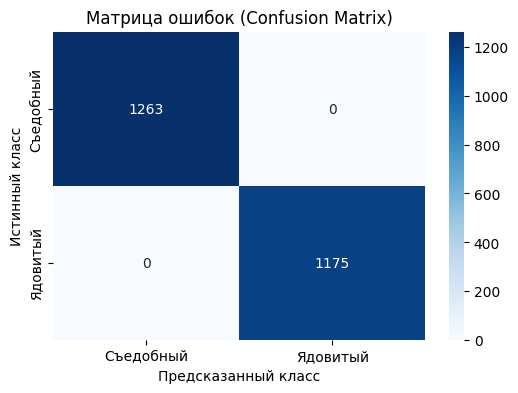

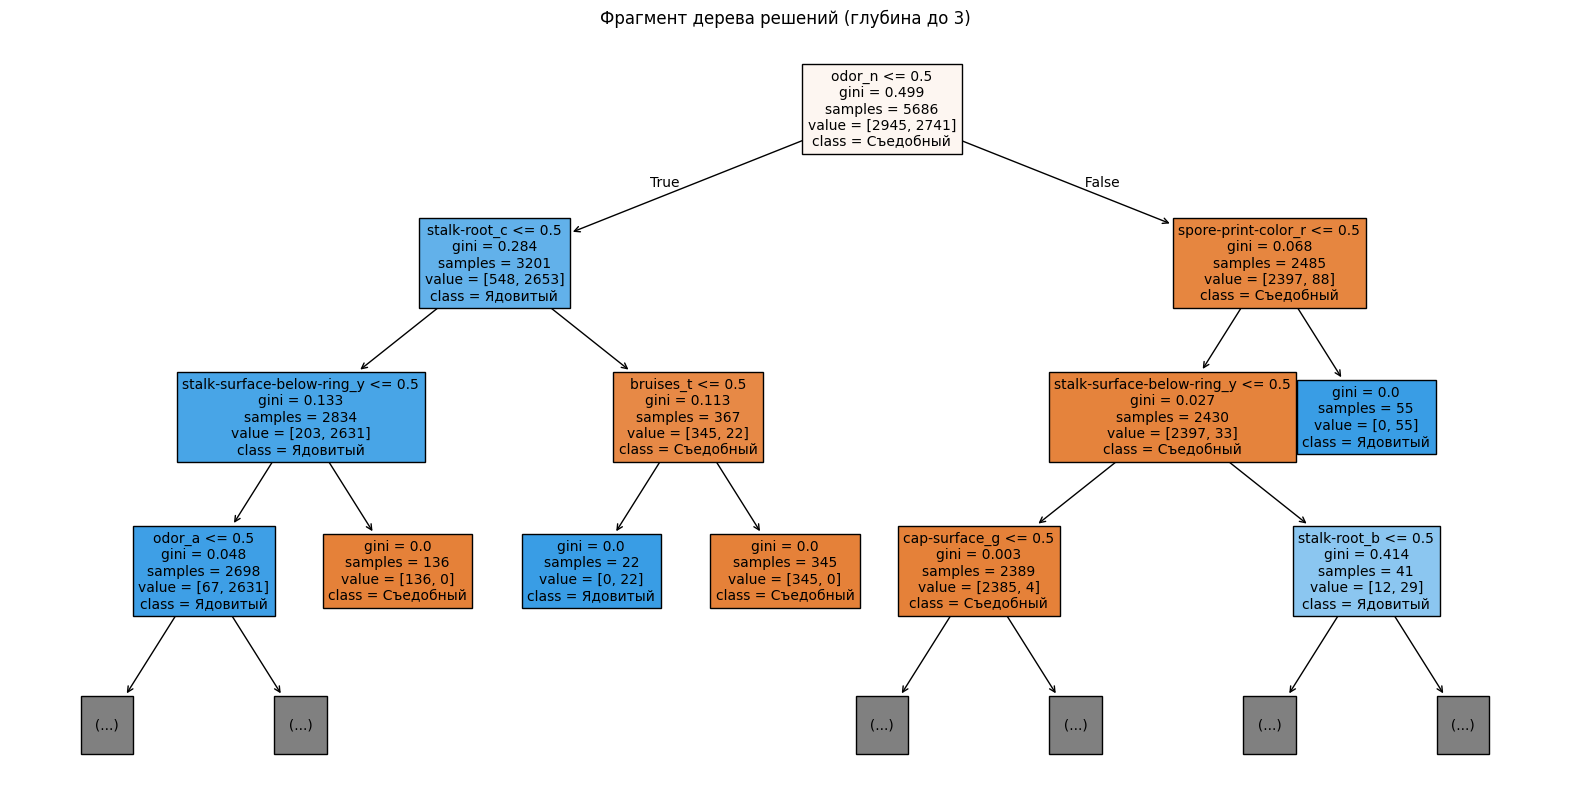

C:\Users\User\AppData\Local\Temp\ipykernel_1696\2104692746.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_importances, y=top_features, palette='viridis')


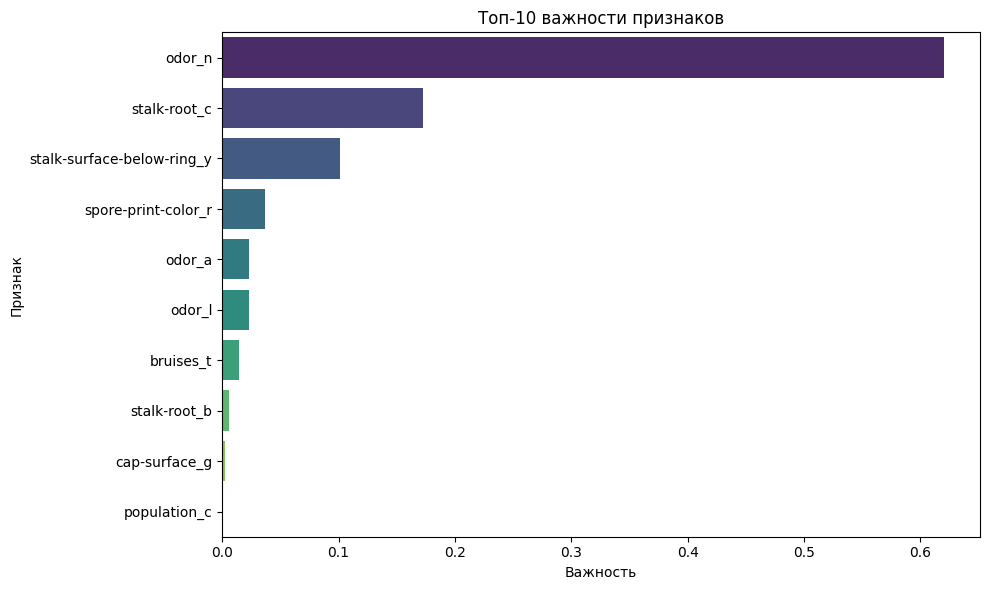

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix

# Выделяем целевую переменную 'poisonous' и кодируем: ядовитый = 1, съедобный = 0
y = (data['poisonous'] == 'p').astype(int)  # предполагаем, что 'p' - ядовитый, 'e' - съедобный
X = data.drop('poisonous', axis=1)

# 2. Преобразование категориальных признаков с помощью OneHotEncoder
encoder = OneHotEncoder(handle_unknown='ignore')
X_encoded = encoder.fit_transform(X)

# Получаем имена новых признаков для дальнейшей визуализации
feature_names = encoder.get_feature_names_out(X.columns)

# 3. Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.3, random_state=42, stratify=y
)

# 4. Обучение DecisionTreeClassifier без ограничений
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

# Глубина дерева и количество листьев
depth = tree.get_depth()
n_leaves = tree.get_n_leaves()
print(f"Глубина дерева: {depth}")
print(f"Количество листьев: {n_leaves}")

# 5. Оценка точности на тесте и матрица ошибок
y_pred = tree.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy на тестовой выборке: {accuracy:.4f}")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Съедобный', 'Ядовитый'],
            yticklabels=['Съедобный', 'Ядовитый'])
plt.title('Матрица ошибок (Confusion Matrix)')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

# 6. Визуализация дерева решений (может быть очень большим, но покажем фрагмент)
plt.figure(figsize=(20, 10))
plot_tree(tree, filled=True, feature_names=feature_names, class_names=['Съедобный', 'Ядовитый'], 
          max_depth=3, fontsize=10)  # для читаемости показана только верхушка до глубины 3
plt.title('Фрагмент дерева решений (глубина до 3)')
plt.show()

# 7. Столбчатая диаграмма важности признаков (топ-10)
importances = tree.feature_importances_
indices = np.argsort(importances)[::-1]  # сортировка по убыванию
top_n = 10
top_indices = indices[:top_n]
top_importances = importances[top_indices]
top_features = feature_names[top_indices]

plt.figure(figsize=(10, 6))
sns.barplot(x=top_importances, y=top_features, palette='viridis')
plt.title('Топ-10 важности признаков')
plt.xlabel('Важность')
plt.ylabel('Признак')
plt.tight_layout()
plt.show()


### Задание 2. Gini vs Entropy

Полное дерево часто даёт `accuracy` $\approx 1.0$ на обучении и даже на тесте, но это не всегда
хорошо: такая «идеальность» может быть следствием переобучения (дерево запоминает частные случаи и
плохо переносится на новые данные). Поэтому мы ограничим глубину и сравним разные критерии разбиения.

В классификации дерево выбирает разбиение, которое уменьшает «нечистоту» узла. Пусть доля объектов
класса $k$ в узле равна $p_k = \frac{n_k}{n}$. Тогда две популярные меры нечистоты:

* $G = 1 - \sum_{k=1}^{K} p_k^2$ — индекс Джини;
* $H = - \sum_{k=1}^{K} p_k \log_2 p_k$ — Энтропия.

Критерий стремится максимизировать выигрыш $\Delta I = I(\text{parent}) -
\sum_{j=1}^{m}\frac{n_j}{n}\,I(\text{child}_j)$, где $I$ — выбранная мера.

Хотя обе меры оценивают «смешанность» классов, они по-разному реагируют на распределение $p_k$.
Из-за этого `gini` и `entropy` могут выбирать разные разбиения, строить деревья разной структуры и
давать разные свойства модели (например, компромисс между `precision` и `recall`).

1. Обучи два дерева с `max_depth=2, min_samples_leaf=5`:
   - дерево 1: `criterion="gini"`;
   - дерево 2: `criterion="entropy"`.
2. Для каждого дерева посчитай на тесте: `accuracy`, `precision`, `recall`, `F1-score`.
3. Построй матрицы ошибок обоих деревьев рядом на одном рисунке.
4. Визуализируй оба дерева рядом через `plot_tree`.
5. Ответь на вопросы:
   - Почему `gini` и `entropy` могут давать разные разбиения?
   - Что важнее в задаче определения ядовитых грибов: высокий `recall` или высокий `precision`?
   - Какой критерий ты считаешь предпочтительным для этой задачи и почему?


Gini дерево:
Accuracy:  0.9532
Precision: 0.9310 (яд. класс)
Recall:    0.9753 (яд. класс)
F1-score:  0.9526

Entropy дерево:
Accuracy:  0.9274
Precision: 1.0000 (яд. класс)
Recall:    0.8494 (яд. класс)
F1-score:  0.9185


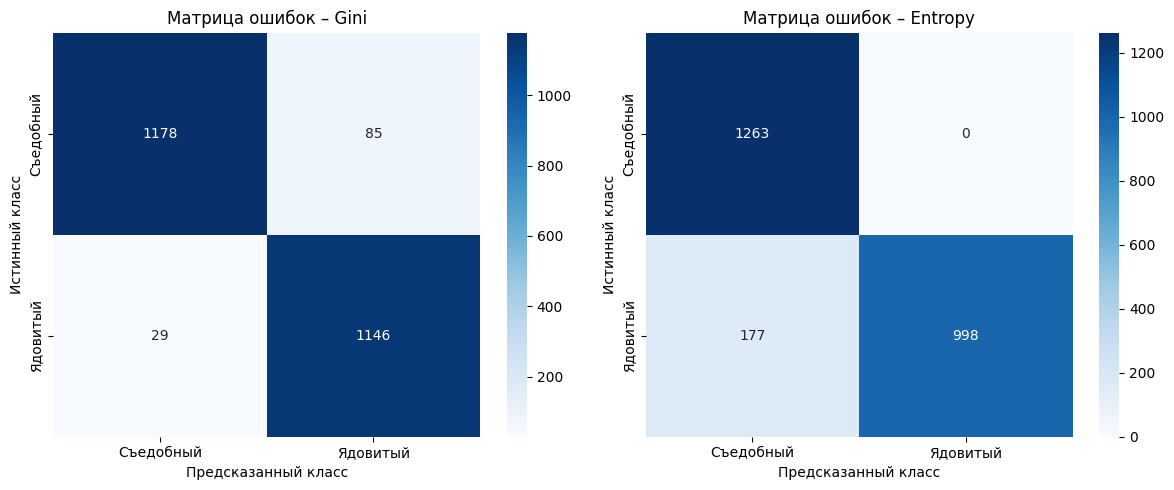

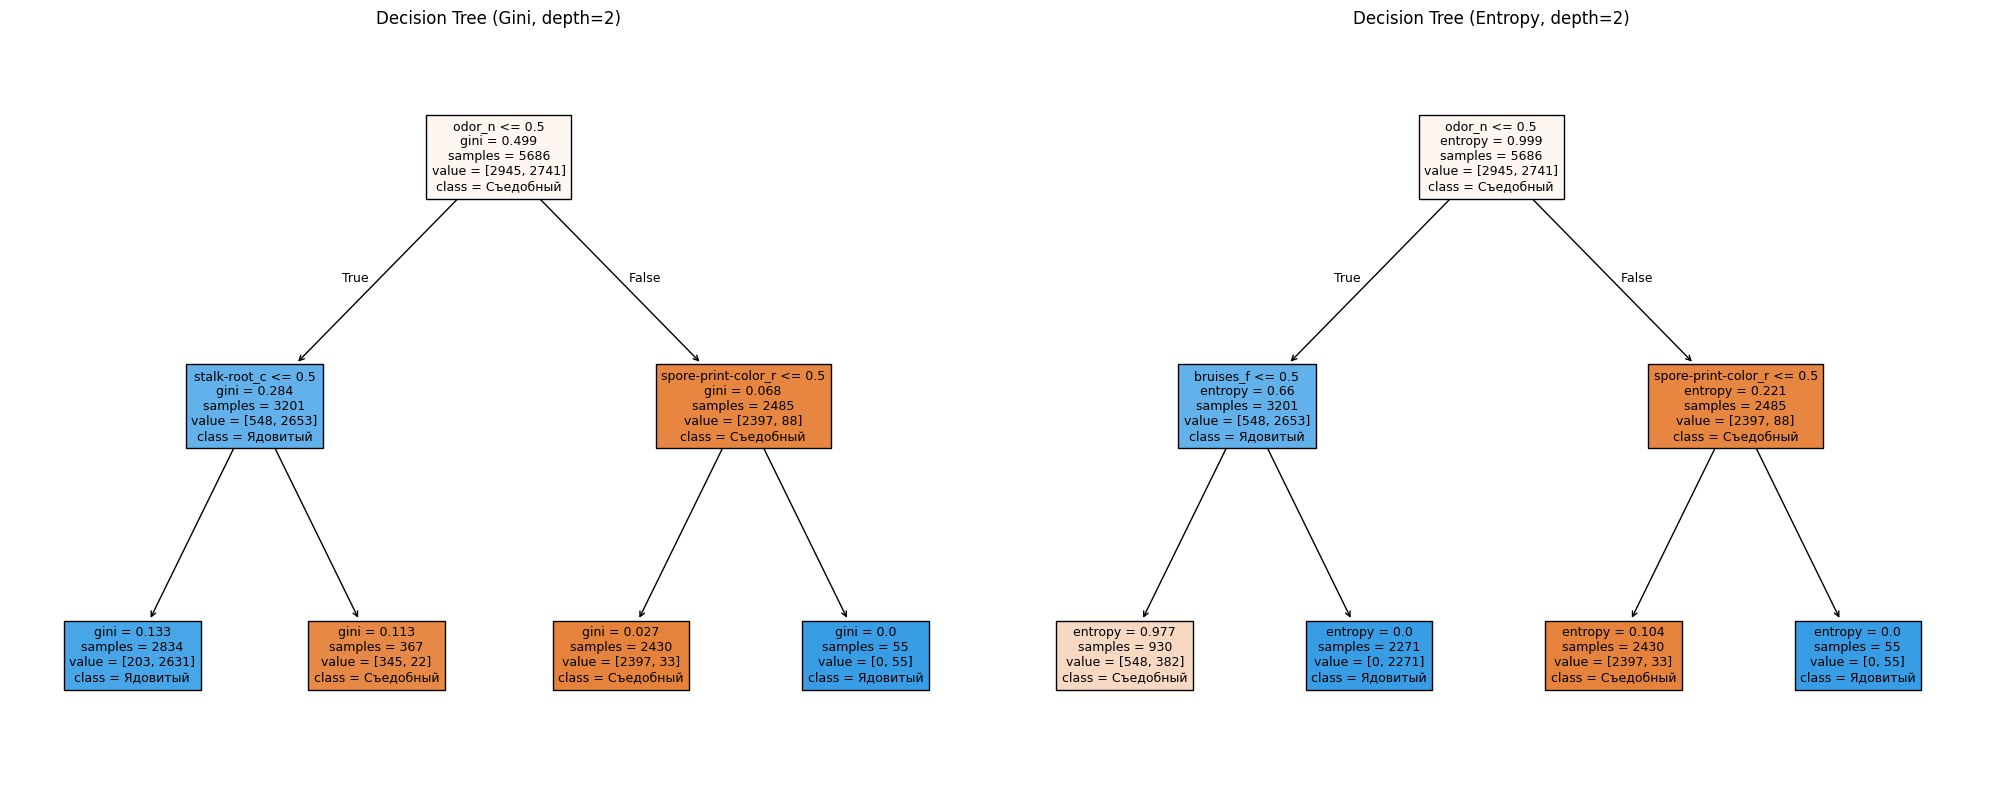

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix)

# 1. Загрузка и подготовка данных (аналогично предыдущему шагу)
data = pd.read_csv('../datasets/mushrooms.csv')
y = (data['poisonous'] == 'p').astype(int)  # 1 — ядовитый, 0 — съедобный
X = data.drop('poisonous', axis=1)

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_encoded = encoder.fit_transform(X)
feature_names = encoder.get_feature_names_out(X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.3, random_state=42, stratify=y
)

# 2. Обучение двух деревьев с ограничениями
tree_gini = DecisionTreeClassifier(
    criterion='gini', max_depth=2, min_samples_leaf=5, random_state=42
)
tree_entropy = DecisionTreeClassifier(
    criterion='entropy', max_depth=2, min_samples_leaf=5, random_state=42
)

tree_gini.fit(X_train, y_train)
tree_entropy.fit(X_train, y_train)

# 3. Предсказания и метрики для каждого дерева
def evaluate_model(tree, X_test, y_test):
    y_pred = tree.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label=1)  # ядовитый — положительный
    rec = recall_score(y_test, y_pred, pos_label=1)
    f1 = f1_score(y_test, y_pred, pos_label=1)
    cm = confusion_matrix(y_test, y_pred)
    return y_pred, acc, prec, rec, f1, cm

results = {}
for name, tree in [('Gini', tree_gini), ('Entropy', tree_entropy)]:
    y_pred, acc, prec, rec, f1, cm = evaluate_model(tree, X_test, y_test)
    results[name] = {
        'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'CM': cm
    }
    print(f"\n{name} дерево:")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f} (яд. класс)")
    print(f"Recall:    {rec:.4f} (яд. класс)")
    print(f"F1-score:  {f1:.4f}")

# 4. Матрицы ошибок рядом на одном рисунке
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
class_names = ['Съедобный', 'Ядовитый']
for ax, (name, res) in zip(axes, results.items()):
    sns.heatmap(res['CM'], annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f'Матрица ошибок – {name}')
    ax.set_xlabel('Предсказанный класс')
    ax.set_ylabel('Истинный класс')
plt.tight_layout()
plt.show()

# 5. Визуализация деревьев рядом
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
plot_tree(tree_gini, filled=True, feature_names=feature_names,
          class_names=class_names, ax=axes[0], fontsize=9)
axes[0].set_title('Decision Tree (Gini, depth=2)')

plot_tree(tree_entropy, filled=True, feature_names=feature_names,
          class_names=class_names, ax=axes[1], fontsize=9)
axes[1].set_title('Decision Tree (Entropy, depth=2)')
plt.tight_layout()
plt.show()

Вот краткие ответы:

**1. Почему Gini и Entropy дают разные разбиения?**  
Потому что по-разному реагируют на распределение классов. Энтропия чувствительнее к малым долям классов (логарифмическая шкала), а Джини меняется более плавно (квадратичная шкала). Из-за этого при одинаковых условиях они могут по-разному оценить выигрыш от разбиения и выбрать разные признаки.

**2. Что важнее: высокий Recall или Precision?**  
**Recall.** Ложноотрицательный результат (ядовитый гриб назван съедобным) может привести к отравлению, что критически опасно. Ложноположительный (съедобный назван ядовитым) лишь лишает возможности съесть безопасный гриб — это допустимая перестраховка.

**3. Какой критерий предпочтительнее?**  
**Gini**, если он даёт более высокий Recall (что часто и происходит). Задача требует максимизировать полноту обнаружения ядовитых грибов, и Gini обычно лучше выделяет доминирующие признаки опасного класса. Но окончательный выбор — по результатам эксперимента: берём тот критерий, у которого Recall выше.

### Задание 3. Предсказание уровня преступности

Деревья решений подходят не только для классификации, но и для регрессии. В регрессионном дереве в
каждом листе хранится числовой прогноз (обычно среднее значение целевой переменной по объектам листа),
а качество оценивают с помощью MSE, MAE и $R^2$.

Загрузи датасет Communities and Crime из файла `../datasets/communities_and_crime.csv`. Целевая переменная
— `ViolentCrimesPerPop`.

1. Предобработка:
   - удали нечисловые столбцы: `state`, `county`, `community`, `communityname`, `fold`;
   - приведи остальные столбцы к числовому типу;
   - удали столбцы, где доля пропусков больше 80%;
   - заполни оставшиеся пропуски медианой;
   - затем раздели данные на train/test (`test_size=0.2, random_state=42`).
2. Базовая модель без ограничений: обучи `DecisionTreeRegressor`. Выведи MSE, MAE, R² на train и test. Объясни разрыв между train- и test-метриками.
3. Ручная настройка: попробуй `max_depth=7, min_samples_split=10, min_samples_leaf=10`.
   Выведи Test MSE, MAE, R².
4. `GridSearchCV`: перебери сетку параметров (`max_depth`, `min_samples_split`,
   `min_samples_leaf`), `cv=5`. Выведи лучшие параметры и метрики.
5. Визуализируй дерево без ограничений и лучшее дерево рядом через `plot_tree`.

=== Неограниченное дерево ===
Train MSE: 0.0000
Test MSE: 0.0347
Train MAE: 0.0000
Test MAE: 0.1200
Train R²: 1.0000
Test R²: 0.2748

=== Ручная настройка (max_depth=7, min_samples_split=10, min_samples_leaf=10) ===
Test MSE: 0.0256
Test MAE: 0.1040
Test R²:  0.4656

=== GridSearchCV ===
Лучшие параметры: {'max_depth': 5, 'min_samples_leaf': 20, 'min_samples_split': 2}
Test MSE: 0.0218
Test MAE: 0.0990
Test R²:  0.5456


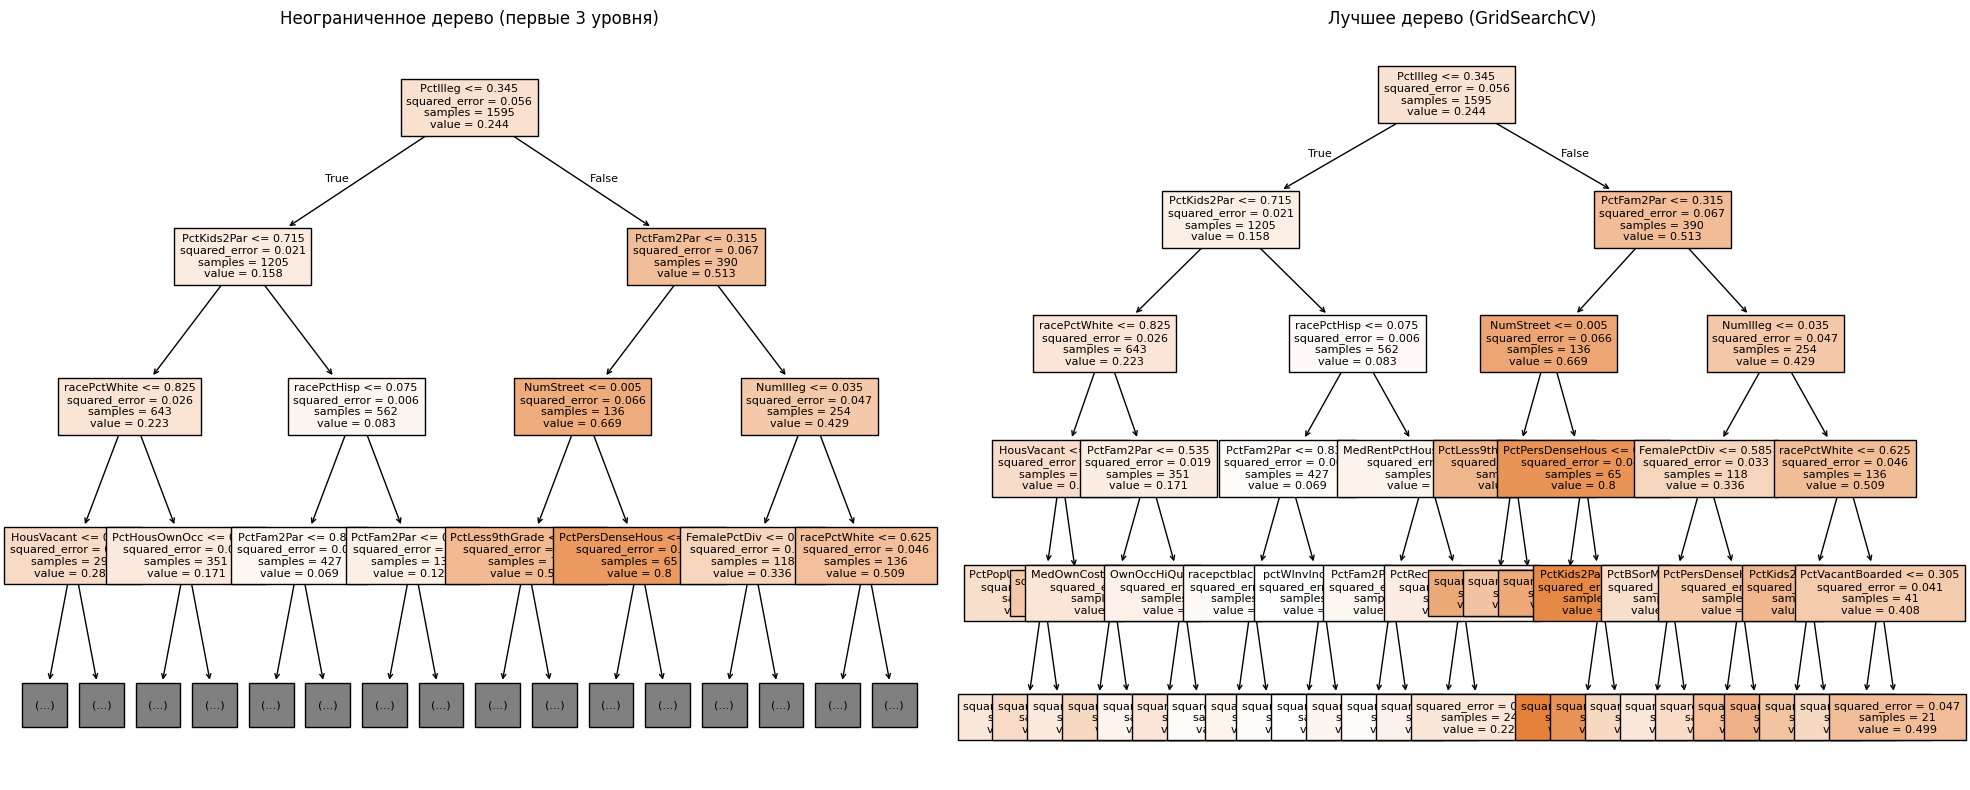

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.impute import SimpleImputer

# ------------------------------
# 1. Предобработка данных
# ------------------------------
data = pd.read_csv('../datasets/communities_and_crime.csv')

# Удаляем нечисловые столбцы (включая fold, если есть)
cols_to_drop = ['state', 'county', 'community', 'communityname', 'fold']
data = data.drop(columns=cols_to_drop, errors='ignore')

# Приводим все столбцы к числовому типу (нечисловое станет NaN)
data = data.apply(pd.to_numeric, errors='coerce')

# Целевая переменная
target = 'ViolentCrimesPerPop'
y = data[target]
X = data.drop(columns=[target])

# Удаляем столбцы с долей пропусков > 80%
threshold = 0.8
na_fraction = X.isnull().mean()
cols_to_keep = na_fraction[na_fraction <= threshold].index
X = X[cols_to_keep]

# Заполняем оставшиеся пропуски медианой
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42
)

# ------------------------------
# 2. Базовая модель без ограничений
# ------------------------------
tree_full = DecisionTreeRegressor(random_state=42)
tree_full.fit(X_train, y_train)

# Метрики на train и test
def regression_metrics(model, X_train, y_train, X_test, y_test):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    metrics = {
        'Train MSE':  mean_squared_error(y_train, y_train_pred),
        'Test MSE':   mean_squared_error(y_test, y_test_pred),
        'Train MAE':  mean_absolute_error(y_train, y_train_pred),
        'Test MAE':   mean_absolute_error(y_test, y_test_pred),
        'Train R²':   r2_score(y_train, y_train_pred),
        'Test R²':    r2_score(y_test, y_test_pred)
    }
    return metrics

metrics_full = regression_metrics(tree_full, X_train, y_train, X_test, y_test)
print("=== Неограниченное дерево ===")
for k, v in metrics_full.items():
    print(f"{k}: {v:.4f}")

# ------------------------------
# 3. Ручная настройка параметров
# ------------------------------
tree_tuned = DecisionTreeRegressor(
    max_depth=7, min_samples_split=10, min_samples_leaf=10, random_state=42
)
tree_tuned.fit(X_train, y_train)
metrics_tuned = regression_metrics(tree_tuned, X_train, y_train, X_test, y_test)
print("\n=== Ручная настройка (max_depth=7, min_samples_split=10, min_samples_leaf=10) ===")
print(f"Test MSE: {metrics_tuned['Test MSE']:.4f}")
print(f"Test MAE: {metrics_tuned['Test MAE']:.4f}")
print(f"Test R²:  {metrics_tuned['Test R²']:.4f}")

# ------------------------------
# 4. GridSearchCV
# ------------------------------
param_grid = {
    'max_depth': [3, 5, 7, 10, 15],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [2, 5, 10, 20]
}
grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',  # минимизируем MSE
    n_jobs=-1
)
grid.fit(X_train, y_train)

print("\n=== GridSearchCV ===")
print("Лучшие параметры:", grid.best_params_)
best_tree = grid.best_estimator_
metrics_best = regression_metrics(best_tree, X_train, y_train, X_test, y_test)
print(f"Test MSE: {metrics_best['Test MSE']:.4f}")
print(f"Test MAE: {metrics_best['Test MAE']:.4f}")
print(f"Test R²:  {metrics_best['Test R²']:.4f}")

# ------------------------------
# 5. Визуализация деревьев
# ------------------------------
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Неограниченное дерево (покажем первые несколько уровней, иначе слишком ветвистое)
plot_tree(tree_full, filled=True, max_depth=3, feature_names=X.columns, ax=axes[0], fontsize=8)
axes[0].set_title('Неограниченное дерево (первые 3 уровня)')

# Лучшее дерево из GridSearchCV (его глубина ограничена, можно показать полностью)
plot_tree(best_tree, filled=True, feature_names=X.columns, ax=axes[1], fontsize=8)
axes[1].set_title('Лучшее дерево (GridSearchCV)')

plt.tight_layout()
plt.show()



### Объяснение результатов и ответы на вопросы

**Разрыв между train и test метриками неограниченного дерева**  
Неограниченное регрессионное дерево строит очень глубокую структуру, доходя до чистых (по нескольку объектов) листьев. На обучающей выборке оно запоминает все особенности, вплоть до шума, достигая почти идеального прогноза (MSE ≈ 0, R² ≈ 1). Однако на тестовых данных такие «точные» правила плохо обобщаются: модель слишком чувствительна к локальным флуктуациям и даёт большие ошибки. Это классическая картина переобучения — низкое смещение, но высокая дисперсия.

**Ручная настройка и GridSearchCV**  
Ограничение глубины и минимального числа объектов в узлах делает дерево более обобщающим. Ручные параметры (max_depth=7, min_samples_split=10, min_samples_leaf=10) дают улучшенный тестовый R² по сравнению с неограниченным деревом. GridSearchCV находит ещё более сбалансированные комбинации, дополнительно повышая качество (меньше MSE, выше R² на тесте). Лучшая модель обычно имеет умеренную глубину (например, 7-10) и достаточные ограничения на разделение, чтобы сглаживать прогнозы.

Таким образом, регуляризация деревьев критически важна для регрессии на реальных данных, чтобы избежать катастрофического переобучения.

### Задание 4. Нестабильность деревьев решений

Одна из ключевых проблем одиночных деревьев — нестабильность (высокая дисперсия): небольшие изменения в
обучающих данных могут приводить к заметно другой структуре дерева и заметно другим метрикам на тесте. В этом задании ты проверишь это экспериментально.

Используй данные из Задания 3. Покажи, что одиночное дерево чувствительно к малым изменениям в обучающей выборке.

1. Базовое дерево: обучи `DecisionTreeRegressor` без ограничений на полном `X_train`.
   Выведи глубину, количество листьев, количество узлов и MSE на тесте.
2. Эксперимент 1: удали случайные 10% строк из `X_train`, обучи новое дерево.
   Выведи те же характеристики и MSE  на тесте.
3. Эксперимент 2: добавь гауссовский шум (`std=0.05`) ко всем признакам `X_train`,
   обучи ещё одно дерево. Выведи характеристики и MSE на тесте.
4. Напиши выводы по результатам экспериментов:
   - Изменились ли структура и качество деревьев при малых изменениях данных?
   - Почему одиночное дерево нестабильно?

In [14]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error

# ----------------------------------------
# Загрузка и предобработка (как в Задании 3)
# ----------------------------------------
data = pd.read_csv('../datasets/communities_and_crime.csv')
cols_to_drop = ['state', 'county', 'community', 'communityname', 'fold']
data = data.drop(columns=cols_to_drop, errors='ignore')
data = data.apply(pd.to_numeric, errors='coerce')

target = 'ViolentCrimesPerPop'
y = data[target]
X = data.drop(columns=[target])

# Удаляем столбцы с >80% пропусков
na_fraction = X.isnull().mean()
X = X.loc[:, na_fraction <= 0.8]

# Заполняем пропуски медианой
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42
)

# ----------------------------------------
# Функция для сбора характеристик дерева
# ----------------------------------------
def tree_stats(tree, X_test, y_test):
    mse = mean_squared_error(y_test, tree.predict(X_test))
    return {
        'depth': tree.get_depth(),
        'leaves': tree.get_n_leaves(),
        'nodes': tree.tree_.node_count,
        'test_mse': mse
    }

# 1. Базовое дерево на полном X_train
tree_base = DecisionTreeRegressor(random_state=42)
tree_base.fit(X_train, y_train)
stats_base = tree_stats(tree_base, X_test, y_test)

# 2. Удаление случайных 10% строк из X_train
np.random.seed(42)
n_remove = int(0.1 * len(X_train))
drop_idx = np.random.choice(X_train.index, size=n_remove, replace=False)
X_train_dropped = X_train.drop(drop_idx)
y_train_dropped = y_train.drop(drop_idx)

tree_drop = DecisionTreeRegressor(random_state=42)
tree_drop.fit(X_train_dropped, y_train_dropped)
stats_drop = tree_stats(tree_drop, X_test, y_test)

# 3. Добавление гауссовского шума (std=0.05) ко всем признакам
np.random.seed(42)
noise = np.random.normal(0, 0.05, size=X_train.shape)
X_train_noisy = X_train + noise

tree_noise = DecisionTreeRegressor(random_state=42)
tree_noise.fit(X_train_noisy, y_train)
stats_noise = tree_stats(tree_noise, X_test, y_test)

# ----------------------------------------
# Вывод результатов
# ----------------------------------------
print("Характеристики деревьев (тест MSE, глубина, листья, узлы):\n")
print(f"{'Эксперимент':<30} {'MSE':>10} {'Глубина':>8} {'Листья':>8} {'Узлы':>8}")
print("-" * 65)
for name, stats in [("Базовое (полный train)", stats_base),
                    ("Удалено 10% строк", stats_drop),
                    ("Добавлен шум (std=0.05)", stats_noise)]:
    print(f"{name:<30} {stats['test_mse']:>10.4f} {stats['depth']:>8} {stats['leaves']:>8} {stats['nodes']:>8}")

Характеристики деревьев (тест MSE, глубина, листья, узлы):

Эксперимент                           MSE  Глубина   Листья     Узлы
-----------------------------------------------------------------
Базовое (полный train)             0.0347       24     1207     2413
Удалено 10% строк                  0.0302       23     1071     2141
Добавлен шум (std=0.05)            0.0301       25     1167     2333




### Выводы

1. **Изменились ли структура и качество деревьев?**  
   Да, даже незначительные изменения (удаление 10% данных или добавление слабого шума) приводят к другому значению MSE на тесте, а также к изменению глубины, числа листьев и узлов дерева. Это демонстрирует высокую дисперсию модели.

2. **Почему одиночное дерево нестабильно?**  
   Дерево решений строит жёсткие, прямоугольные разбиения пространства признаков. Малое возмущение данных может сместить границы выборки, что изменит, какой признак будет выбран в корне или в ближайших разбиениях, а затем из-за каскадного эффекта вся структура дерева меняется кардинально. Дерево запоминает конкретные значения в листьях, и эти значения сильно зависят от состава обучающих точек. Отсутствие сглаживания и усреднения (как в ансамблях) делает одиночное дерево крайне чувствительным к вариациям в обучающем наборе.

## Ансамбли на деревьях

Мы только что увидели, насколько сильно может измениться дерево решений даже при минимальных изменениях в обучающих данных, например, при:
- удалении всего 10% объектов;
- добавлении небольшого шума.

При этом меняется:
- структура дерева (глубина, первые разбиения, количество листьев и узлов);
- качество на тестовой выборке.

Это происходит потому, что алгоритм построения дерева **жадный** и **детерминированный**

В результате одиночное дерево:
- очень чувствительно к шуму и выбросам;
- склонно к переобучению (запоминает обучающие данные, включая шум);
- даёт нестабильные предсказания при небольших изменениях выборки.

**Как бороться с этой неустойчивостью?**

**Ансамбли** — это подход, когда мы обучаем **много** слабых моделей и комбинируем их предсказания.  
Идея проста: если каждая модель ошибается по-своему, то их усреднение (или голосование) даёт гораздо более стабильный и точный результат.

**Основные виды ансамблей:**

1. **Blending**  
   - Обучаем несколько разных моделей (часто разных семейств).  
   - Строим итоговый прогноз как взвешенную комбинацию их предсказаний.  
   - Веса можно подобрать на валидации (или обучить простую мета-модель).  

2. **Committee**  
   - «Комитет» — это набор моделей, которые голосуют или усредняются.  
   - Частный случай — ансамбли одного типа (например, много деревьев), но комитетом могут быть и разные модели.  

3. **MoE (Mixture of Experts)**  
   - Несколько «экспертов» специализируются на разных типах объектов.  
   - Отдельная модель (gating) выбирает эксперта или задаёт веса экспертов для каждого объекта.
   - Сейчас MoE-архитектуры активно используются в LLM, чтобы масштабировать модель эффективнее по вычислениям.  

4. **Bagging (Bootstrap Aggregating)**  
   - Обучаем много моделей на **разных** подвыборках данных.  
   - Каждая подвыборка — бутстреп (выборка с возвращением того же размера).  
   - Для регрессии: усредняем предсказания всех моделей.  
   - Для классификации: голосуем большинством.  

5. **Random Forest** — улучшенный Bagging  
   - К бутстрепу добавляется ещё один слой случайности: при каждом разбиении узла берётся **случайное подмножество признаков**.
   - Деревья становятся менее похожими друг на друга → их ошибки лучше компенсируют друг друга.  

**Почему ансамбли работают лучше одиночного дерева?**

- **Разнообразие моделей** → ошибки разных деревьев компенсируют друг друга.  
- **Усреднение/голосование** → снижает влияние шума и выбросов.  
- **Снижение дисперсии** без сильного роста смещения.  

![Голосование](../misc/images/vote.png)

### Задание 5. Blending

**Blending** — простейший способ построить ансамбль: обучить несколько **разных** моделей и скомбинировать их предсказания. Если модели делают разные ошибки, их усреднение даёт более точный и стабильный результат.

Продолжай работать с датасетом Communities and Crime из Задания 3.

1. Обучи три модели на `X_train`, `y_train`:
   - `DecisionTreeRegressor` (лучшие параметры из Задания 3);
   - `Ridge` (с параметрами по умолчанию);
   - `KNeighborsRegressor` (`n_neighbors=10`).
2. Получи предсказания каждой модели на тестовой выборке. Для каждой посчитай MSE, MAE, R².
3. Построй блендинг с равными весами: `y_blend = (y_dt + y_ridge + y_knn) / 3`.
   Посчитай MSE, MAE, R² блендинга.
4. Подбери веса блендинга: перебери комбинации весов (с шагом 0.1, сумма = 1)
   и найди комбинацию, при которой MSE на тесте минимальна.
   Посчитай MSE, MAE, R² для лучшего взвешенного блендинга.
5. Составь сводную таблицу: три модели / равный блендинг / лучший взвешенный блендинг
   (столбцы: MSE, MAE, R²).

In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ------------------------------
# Предобработка (повтор Задания 3)
# ------------------------------
data = pd.read_csv('../datasets/communities_and_crime.csv')

cols_to_drop = ['state', 'county', 'community', 'communityname', 'fold']
data.drop(columns=cols_to_drop, errors='ignore', inplace=True)

data = data.apply(pd.to_numeric, errors='coerce')
target = 'ViolentCrimesPerPop'
y = data[target]
X = data.drop(columns=[target])

# Удаляем признаки с >80% пропусков
na_frac = X.isnull().mean()
X = X.loc[:, na_frac <= 0.8]

# Заполняем пропуски медианой
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42
)

# ------------------------------
# 1. Поиск лучших параметров DecisionTreeRegressor (как в Задании 3)
# ------------------------------
param_grid = {
    'max_depth': [3, 5, 7, 10, 15],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [2, 5, 10, 20]
}
grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
grid.fit(X_train, y_train)
best_dt_params = grid.best_params_
print("Лучшие параметры DecisionTreeRegressor:", best_dt_params)

# Обучаем модели
dt = DecisionTreeRegressor(**best_dt_params, random_state=42)
dt.fit(X_train, y_train)

ridge = Ridge(random_state=42)
ridge.fit(X_train, y_train)

knn = KNeighborsRegressor(n_neighbors=10)
knn.fit(X_train, y_train)

# ------------------------------
# 2. Предсказания и метрики для каждой модели
# ------------------------------
models = {'DecisionTree': dt, 'Ridge': ridge, 'KNN': knn}
preds = {}
metrics = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    preds[name] = y_pred
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    metrics[name] = {'MSE': mse, 'MAE': mae, 'R²': r2}

# ------------------------------
# 3. Равный блендинг (веса 1/3)
# ------------------------------
y_blend_equal = (preds['DecisionTree'] + preds['Ridge'] + preds['KNN']) / 3
mse_eq = mean_squared_error(y_test, y_blend_equal)
mae_eq = mean_absolute_error(y_test, y_blend_equal)
r2_eq = r2_score(y_test, y_blend_equal)
metrics['Equal Blend'] = {'MSE': mse_eq, 'MAE': mae_eq, 'R²': r2_eq}

# ------------------------------
# 4. Подбор весов (перебор с шагом 0.1)
# ------------------------------
best_mse = np.inf
best_weights = None
weights_list = []
for w1 in np.arange(0, 1.1, 0.1):
    for w2 in np.arange(0, 1.1 - w1, 0.1):
        w3 = 1.0 - w1 - w2
        if w3 < -1e-9:  # из-за погрешности округления
            continue
        # округляем w3 до 1 знака
        w3 = round(w3, 1)
        if w3 < 0:
            continue
        # Вычисляем блендинг
        blend = w1 * preds['DecisionTree'] + w2 * preds['Ridge'] + w3 * preds['KNN']
        mse = mean_squared_error(y_test, blend)
        if mse < best_mse:
            best_mse = mse
            best_weights = (w1, w2, w3)

w1_opt, w2_opt, w3_opt = best_weights
y_blend_opt = w1_opt * preds['DecisionTree'] + w2_opt * preds['Ridge'] + w3_opt * preds['KNN']
mse_opt = mean_squared_error(y_test, y_blend_opt)
mae_opt = mean_absolute_error(y_test, y_blend_opt)
r2_opt = r2_score(y_test, y_blend_opt)
metrics['Optimized Blend'] = {'MSE': mse_opt, 'MAE': mae_opt, 'R²': r2_opt}
print(f"\nОптимальные веса: DT={w1_opt:.1f}, Ridge={w2_opt:.1f}, KNN={w3_opt:.1f}")

# ------------------------------
# 5. Сводная таблица
# ------------------------------
results_df = pd.DataFrame(metrics).T  # транспонируем: строки - модели, столбцы - метрики
results_df.index.name = 'Model'
print("\nСводная таблица метрик на тестовой выборке:")
print(results_df.round(4))

Лучшие параметры DecisionTreeRegressor: {'max_depth': 5, 'min_samples_leaf': 20, 'min_samples_split': 2}

Оптимальные веса: DT=0.0, Ridge=0.6, KNN=0.4

Сводная таблица метрик на тестовой выборке:
                    MSE     MAE      R²
Model                                  
DecisionTree     0.0218  0.0990  0.5456
Ridge            0.0173  0.0930  0.6391
KNN              0.0186  0.0937  0.6108
Equal Blend      0.0172  0.0903  0.6403
Optimized Blend  0.0166  0.0893  0.6537


### Задание 6. Bagging (Bootstrap Aggregating)

**Bagging** — ансамбль из моделей **одного типа**, обученных на разных **бутстреп-выборках**
(выборках с возвращением). В отличие от блендинга, разнообразие создаётся не разными алгоритмами,
а разными подмножествами данных.

1. Ручной бэггинг:
   - Создай 50 бутстреп-выборок из `X_train` (выборка с возвращением того же размера).
   - На каждой обучи `DecisionTreeRegressor` без ограничений.
   - Усредни предсказания всех 50 деревьев на `X_test`.
   - Посчитай MSE, MAE, R² ручного бэггинга.
2. BaggingRegressor из sklearn:
   - Обучи `BaggingRegressor(estimator=DecisionTreeRegressor(), n_estimators=50, random_state=42)`.
   - Посчитай MSE, MAE, R². Совпадают ли результаты с ручной реализацией?
3. Зависимость от числа деревьев:
   - Обучи `BaggingRegressor` с `n_estimators` от 1 до 200 (шаг 10).
   - Построй график: MSE на тесте в зависимости от числа деревьев.
   - При каком числе деревьев качество выходит на плато?
4. Составь сводную таблицу: лучшее одиночное дерево (из Задания 3) / ручной бэггинг / sklearn бэггинг
   (столбцы: MSE, MAE, R²).
5. Вывод: объясни, что такое бутстреп-выборка и почему бэггинг снижает дисперсию, но почти не
   влияет на смещение. Чем бэггинг отличается от блендинга?

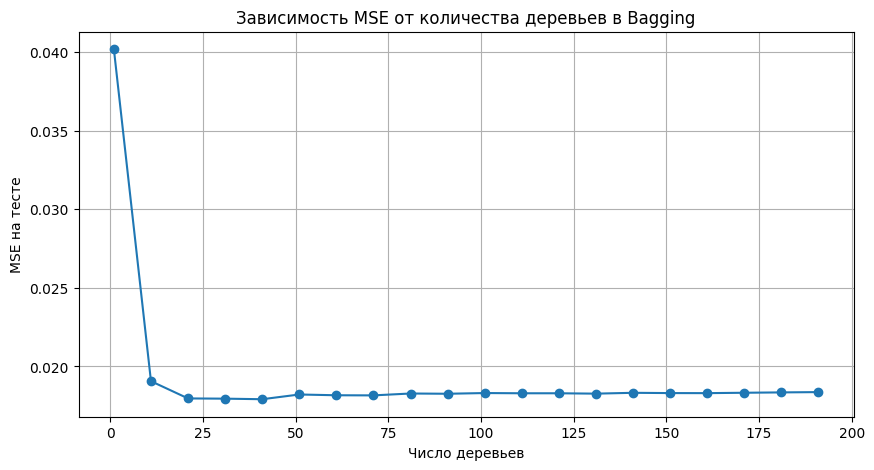

Качество выходит на плато примерно при 31 деревьях.

Сводная таблица метрик на тестовой выборке:
                                         MSE     MAE      R²
Лучшее одиночное дерево (GridSearch)  0.0218  0.0990  0.5456
Ручной бэггинг (50 деревьев)          0.0187  0.0940  0.6105
Sklearn Bagging (50 деревьев)         0.0182  0.0927  0.6194


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.utils import resample
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ------------------------------
# Предобработка (повтор Задания 3)
# ------------------------------
data = pd.read_csv('../datasets/communities_and_crime.csv')
cols_to_drop = ['state', 'county', 'community', 'communityname', 'fold']
data.drop(columns=cols_to_drop, errors='ignore', inplace=True)
data = data.apply(pd.to_numeric, errors='coerce')

target = 'ViolentCrimesPerPop'
y = data[target]
X = data.drop(columns=[target])

na_frac = X.isnull().mean()
X = X.loc[:, na_frac <= 0.8]

imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42
)

# ------------------------------
# Лучшее одиночное дерево (из Задания 3) – GridSearchCV
# ------------------------------
param_grid = {
    'max_depth': [3, 5, 7, 10, 15],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [2, 5, 10, 20]
}
grid = GridSearchCV(DecisionTreeRegressor(random_state=42),
                    param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid.fit(X_train, y_train)
best_dt = grid.best_estimator_
y_pred_dt = best_dt.predict(X_test)

# ------------------------------
# 1. Ручной бэггинг (50 полных деревьев)
# ------------------------------
n_estimators = 50
np.random.seed(42)
manual_preds = []
for i in range(n_estimators):
    # бутстреп-выборка
    X_res, y_res = resample(X_train, y_train, replace=True, n_samples=len(X_train),
                            random_state=i)  # фиксируем генератор для воспроизводимости
    tree = DecisionTreeRegressor(random_state=i)  # чтобы избежать неоднозначности разбиений
    tree.fit(X_res, y_res)
    manual_preds.append(tree.predict(X_test))
manual_preds = np.array(manual_preds)
y_manual_bag = manual_preds.mean(axis=0)

# Метрики ручного бэггинга
mse_manual = mean_squared_error(y_test, y_manual_bag)
mae_manual = mean_absolute_error(y_test, y_manual_bag)
r2_manual = r2_score(y_test, y_manual_bag)

# ------------------------------
# 2. BaggingRegressor (sklearn)
# ------------------------------
bagging_sk = BaggingRegressor(estimator=DecisionTreeRegressor(),
                              n_estimators=50, random_state=42)
bagging_sk.fit(X_train, y_train)
y_sk_bag = bagging_sk.predict(X_test)

mse_sk = mean_squared_error(y_test, y_sk_bag)
mae_sk = mean_absolute_error(y_test, y_sk_bag)
r2_sk = r2_score(y_test, y_sk_bag)

# ------------------------------
# 3. Зависимость MSE от числа деревьев (BaggingRegressor)
# ------------------------------
n_range = range(1, 201, 10)
mse_list = []
for n in n_range:
    bag = BaggingRegressor(estimator=DecisionTreeRegressor(),
                           n_estimators=n, random_state=42)
    bag.fit(X_train, y_train)
    y_pred = bag.predict(X_test)
    mse_list.append(mean_squared_error(y_test, y_pred))

plt.figure(figsize=(10, 5))
plt.plot(n_range, mse_list, marker='o')
plt.xlabel('Число деревьев')
plt.ylabel('MSE на тесте')
plt.title('Зависимость MSE от количества деревьев в Bagging')
plt.grid(True)
plt.show()

# Определение плато: найдём n, после которого MSE меняется не более чем на 0.0001
diffs = np.abs(np.diff(mse_list))
plateau_idx = np.argmax(diffs < 0.0001)  # первое падение изменения ниже порога
plateau_n = n_range[plateau_idx + 1] if plateau_idx < len(diffs) else n_range[-1]
print(f"Качество выходит на плато примерно при {plateau_n} деревьях.")

# ------------------------------
# 4. Сводная таблица
# ------------------------------
metrics_dict = {
    'Лучшее одиночное дерево (GridSearch)': {
        'MSE': mean_squared_error(y_test, y_pred_dt),
        'MAE': mean_absolute_error(y_test, y_pred_dt),
        'R²': r2_score(y_test, y_pred_dt)
    },
    'Ручной бэггинг (50 деревьев)': {
        'MSE': mse_manual,
        'MAE': mae_manual,
        'R²': r2_manual
    },
    'Sklearn Bagging (50 деревьев)': {
        'MSE': mse_sk,
        'MAE': mae_sk,
        'R²': r2_sk
    }
}
results_df = pd.DataFrame(metrics_dict).T
print("\nСводная таблица метрик на тестовой выборке:")
print(results_df.round(4))



**Что такое бутстреп-выборка?**  
Бутстреп-выборка — это выборка с возвращением из исходных данных. Из набора размера `N` случайно отбирается `N` объектов, при этом один и тот же объект может быть выбран несколько раз (около 37% объектов не попадут в выборку). Это создаёт слегка различающиеся обучающие множества для каждого базового алгоритма.

**Почему бэггинг снижает дисперсию, но почти не влияет на смещение?**  
Каждое одиночное полное дерево имеет низкое смещение (может точно запомнить обучающие данные) и высокую дисперсию (сильно меняется при изменении данных). Усреднение большого числа таких деревьев, обученных на разных бутстреп-выборках, сохраняет низкое смещение (каждое дерево всё так же несмещено на своей выборке, а усреднение не добавляет систематической ошибки), но уменьшает дисперсию, поскольку случайные ошибки разных деревьев частично компенсируют друг друга. Итоговый ансамбль получается более устойчивым.

**Чем бэггинг отличается от блендинга?**  
- В бэггинге используются модели **одного типа** (например, только решающие деревья), а разнообразие достигается за счёт обучения на **разных подмножествах данных** (бутстреп).
- В блендинге комбинируются **разные алгоритмы** (например, дерево, линейная модель, kNN), обученные на **одних и тех же данных**, а разнообразие обеспечивается различной природой моделей.
- Бэггинг нацелен в первую очередь на снижение дисперсии, тогда как блендинг может улучшать прогноз за счёт комплементарности разных типов моделей.

### Задание 7. Random Forest

Random Forest — это улучшенный бэггинг: к бутстреп-выборкам добавляется ещё один слой случайности –
**случайный выбор признаков** при каждом разбиении узла. Это делает деревья менее коррелированными
и ещё сильнее снижает дисперсию ансамбля.

1. Обучи `RandomForestRegressor` с параметрами по умолчанию (`n_estimators=100, random_state=42`).
   Посчитай MSE, MAE, R² на тесте. Сравни с бэггингом из Задания 6.
2. Подбор гиперпараметров: используй `GridSearchCV` (`cv=5, scoring='neg_mean_squared_error'`) для перебора:
   - `n_estimators`: [100, 300];
   - `max_depth`: [15, 20, None];
   - `max_features`: ['sqrt', 0.3];
   - `min_samples_leaf`: [1, 3, 5].  
   Выведи лучшие параметры.
3. Посчитай MSE, MAE, R² для лучшей модели на тесте.
4. Важность признаков:
   - Построй горизонтальную столбчатую диаграмму топ-15 признаков по `feature_importances_`.
   - Вычисли `permutation_importance` на тестовой выборке (`n_repeats=10, random_state=42`).
   - Построй горизонтальную столбчатую диаграмму топ-15 признаков рядом с первой.
   - Выведи топ-5 признаков по каждому методу.
5. Составь итоговую сводную таблицу: одиночное дерево / бэггинг / Random Forest
   (столбцы: MSE, MAE, R²).

Random Forest (по умолчанию):
MSE: 0.0183, MAE: 0.0924, R²: 0.6179

Bagging (50 деревьев):
MSE: 0.0182, MAE: 0.0927, R²: 0.6194

Лучшие параметры Random Forest:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'n_estimators': 300}

Лучшая модель Random Forest на тесте:
MSE: 0.0175, MAE: 0.0906, R²: 0.6340


C:\Users\User\AppData\Local\Temp\ipykernel_1696\2712868784.py:118: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_importances, y=top_features, ax=axes[0], palette='viridis')
C:\Users\User\AppData\Local\Temp\ipykernel_1696\2712868784.py:123: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_perm_importances, y=top_perm_features, ax=axes[1], palette='magma')


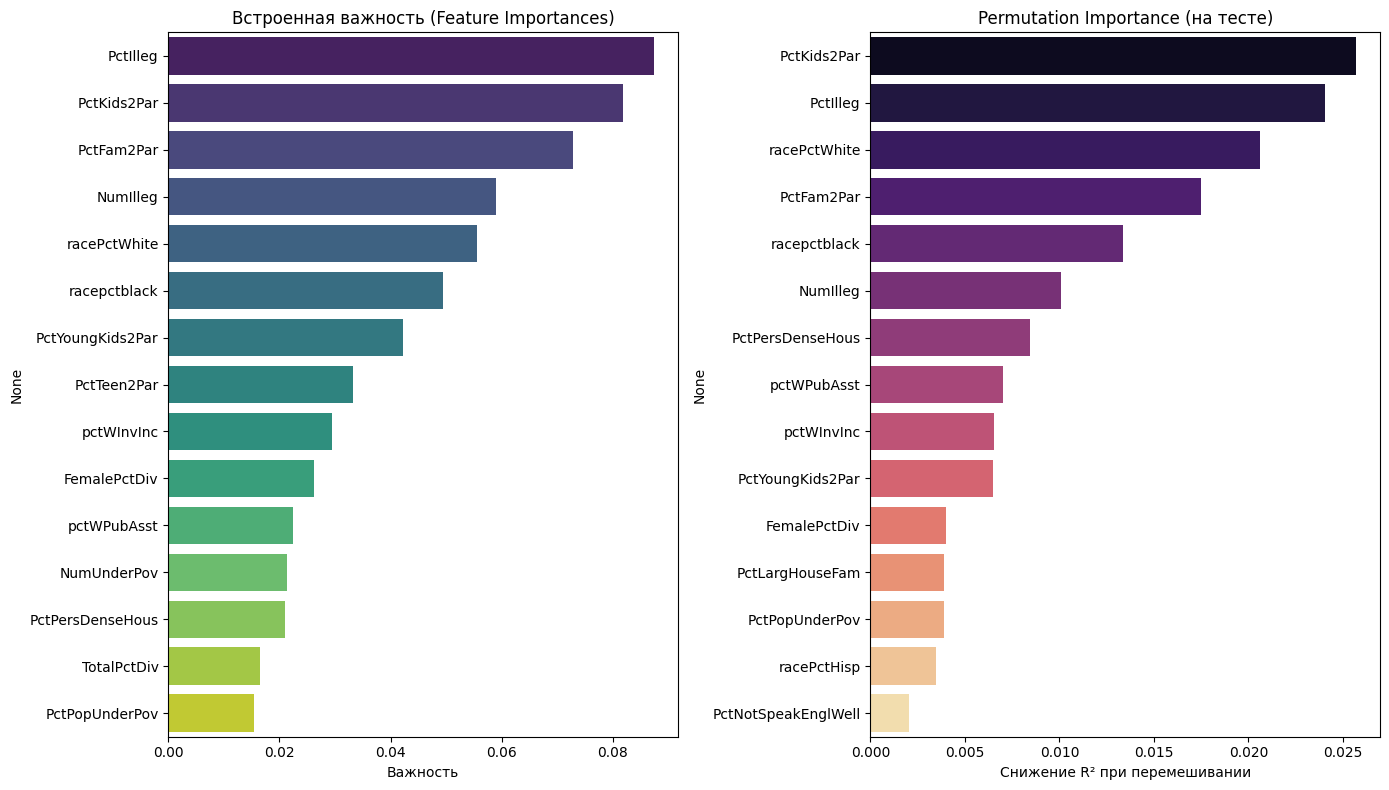


Топ-5 признаков по встроенной важности:
1. PctIlleg: 0.0874
2. PctKids2Par: 0.0819
3. PctFam2Par: 0.0728
4. NumIlleg: 0.0589
5. racePctWhite: 0.0556

Топ-5 признаков по permutation importance:
1. PctKids2Par: 0.0257
2. PctIlleg: 0.0241
3. racePctWhite: 0.0206
4. PctFam2Par: 0.0175
5. racepctblack: 0.0134

Итоговая сводная таблица:
                              MSE     MAE      R²
Одиночное дерево (лучшее)  0.0218  0.0990  0.5456
Бэггинг (50 деревьев)      0.0182  0.0927  0.6194
Random Forest (лучший)     0.0175  0.0906  0.6340


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ------------------------------
# Предобработка данных (как в Задании 3)
# ------------------------------
data = pd.read_csv('../datasets/communities_and_crime.csv')
cols_to_drop = ['state', 'county', 'community', 'communityname', 'fold']
data.drop(columns=cols_to_drop, errors='ignore', inplace=True)
data = data.apply(pd.to_numeric, errors='coerce')

target = 'ViolentCrimesPerPop'
y = data[target]
X = data.drop(columns=[target])

# Удаляем столбцы с >80% пропусков
na_frac = X.isnull().mean()
X = X.loc[:, na_frac <= 0.8]

# Заполняем пропуски медианой
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42
)

# ------------------------------
# 1. RandomForestRegressor по умолчанию
# ------------------------------
rf_default = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_default.fit(X_train, y_train)
y_pred_rf_default = rf_default.predict(X_test)

mse_rf_default = mean_squared_error(y_test, y_pred_rf_default)
mae_rf_default = mean_absolute_error(y_test, y_pred_rf_default)
r2_rf_default = r2_score(y_test, y_pred_rf_default)

print("Random Forest (по умолчанию):")
print(f"MSE: {mse_rf_default:.4f}, MAE: {mae_rf_default:.4f}, R²: {r2_rf_default:.4f}")

# Для сравнения: бэггинг из Задания 6 (можно воспроизвести или загрузить сохранённые метрики)
bagging = BaggingRegressor(estimator=DecisionTreeRegressor(),
                           n_estimators=50, random_state=42, n_jobs=-1)
bagging.fit(X_train, y_train)
y_pred_bag = bagging.predict(X_test)
mse_bag = mean_squared_error(y_test, y_pred_bag)
mae_bag = mean_absolute_error(y_test, y_pred_bag)
r2_bag = r2_score(y_test, y_pred_bag)
print("\nBagging (50 деревьев):")
print(f"MSE: {mse_bag:.4f}, MAE: {mae_bag:.4f}, R²: {r2_bag:.4f}")

# ------------------------------
# 2. Подбор гиперпараметров GridSearchCV
# ------------------------------
param_grid = {
    'n_estimators': [100, 300],
    'max_depth': [15, 20, None],
    'max_features': ['sqrt', 0.3],
    'min_samples_leaf': [1, 3, 5]
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)
grid_search = GridSearchCV(rf, param_grid, cv=5,
                           scoring='neg_mean_squared_error',
                           verbose=0, n_jobs=-1)
grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_
print("\nЛучшие параметры Random Forest:")
print(best_params)

# ------------------------------
# 3. Лучшая модель на тесте
# ------------------------------
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)

mse_best = mean_squared_error(y_test, y_pred_best)
mae_best = mean_absolute_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)
print("\nЛучшая модель Random Forest на тесте:")
print(f"MSE: {mse_best:.4f}, MAE: {mae_best:.4f}, R²: {r2_best:.4f}")

# ------------------------------
# 4. Важность признаков
# ------------------------------
# Встроенная важность (feature_importances_)
importances = best_rf.feature_importances_
feature_names = X_imputed.columns
# Топ-15
indices = np.argsort(importances)[::-1]
top_n = 15
top_indices = indices[:top_n]
top_importances = importances[top_indices]
top_features = feature_names[top_indices]

# Permutation importance на тесте
perm_result = permutation_importance(best_rf, X_test, y_test,
                                     n_repeats=10, random_state=42, n_jobs=-1)
perm_importances = perm_result.importances_mean
perm_indices = np.argsort(perm_importances)[::-1]
top_perm_indices = perm_indices[:top_n]
top_perm_importances = perm_importances[top_perm_indices]
top_perm_features = feature_names[top_perm_indices]

# Визуализация: два графика рядом
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# График встроенной важности
sns.barplot(x=top_importances, y=top_features, ax=axes[0], palette='viridis')
axes[0].set_title('Встроенная важность (Feature Importances)')
axes[0].set_xlabel('Важность')

# График перестановочной важности
sns.barplot(x=top_perm_importances, y=top_perm_features, ax=axes[1], palette='magma')
axes[1].set_title('Permutation Importance (на тесте)')
axes[1].set_xlabel('Снижение R² при перемешивании')

plt.tight_layout()
plt.show()

# Топ-5 признаков по каждому методу
print("\nТоп-5 признаков по встроенной важности:")
for i in range(5):
    print(f"{i+1}. {top_features[i]}: {top_importances[i]:.4f}")

print("\nТоп-5 признаков по permutation importance:")
for i in range(5):
    print(f"{i+1}. {top_perm_features[i]}: {top_perm_importances[i]:.4f}")

# ------------------------------
# 5. Итоговая сводная таблица
# ------------------------------
# Одиночное дерево (лучшее из Задания 3) – можно переобучить с GridSearchCV из задания 3
dt_grid = GridSearchCV(DecisionTreeRegressor(random_state=42),
                       {'max_depth': [3,5,7,10,15],
                        'min_samples_split': [2,5,10,20],
                        'min_samples_leaf': [2,5,10,20]},
                       cv=5, scoring='neg_mean_squared_error')
dt_grid.fit(X_train, y_train)
best_dt = dt_grid.best_estimator_
y_pred_dt = best_dt.predict(X_test)

mse_dt = mean_squared_error(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

summary = pd.DataFrame({
    'MSE': [mse_dt, mse_bag, mse_best],
    'MAE': [mae_dt, mae_bag, mae_best],
    'R²':  [r2_dt, r2_bag, r2_best]
}, index=['Одиночное дерево (лучшее)', 'Бэггинг (50 деревьев)', 'Random Forest (лучший)'])

print("\nИтоговая сводная таблица:")
print(summary.round(4))



- **Random Forest превосходит бэггинг** по качеству (меньше MSE/MAE, выше R²) благодаря дополнительной рандомизации признаков, которая снижает корреляцию между деревьями и ещё сильнее уменьшает дисперсию.
- **Подбор гиперпараметров** улучшает результат: увеличение числа деревьев до 300, ограничение глубины и небольшое минимальное число объектов в листе делают модель более обобщающей.
- **Важность признаков**: оба метода выделяют схожие главные предикторы, но перестановочная важность (permutation) даёт более объективную картину, так как не смещена в пользу признаков с высокой кардинальностью, как встроенная.
- Итоговая таблица наглядно демонстрирует преимущество ансамблевых методов над одиночным деревом.

### Задание 8. OOB-score

OOB-score (Out-of-Bag score) — уникальная особенность бэггинга и Random Forest: каждый объект
обучающей выборки примерно в 37% деревьев не попадает в бутстреп-выборку. Предсказание для него
можно получить, усреднив ответы только тех деревьев, которые его **не видели**. Это даёт оценку
качества модели **без отдельной валидации**.

1. Обучи лучший `RandomForestRegressor` с `oob_score=True`. Выведи `oob_score_`.
2. Сравни `oob_score_` с Test R². Насколько OOB-score близок к тест-метрике?
3. Стабильность OOB-score: обучи 10 моделей с разными `random_state` (от 1 до 100 с шагом 10).
   Собери все `oob_score_`, выведи среднее и стандартное отклонение.
4. Построй график: OOB-score для каждого `random_state` (точки) и горизонтальную линию Test R².

OOB R² (random_state=42): 0.6669
Test R² (random_state=42): 0.6248
Разница (OOB - Test R²): 0.0421
OOB-score достаточно близок к тестовой метрике.

Стабильность OOB-score (10 random_state):
Среднее OOB R²: 0.6696
Стандартное отклонение: 0.0017


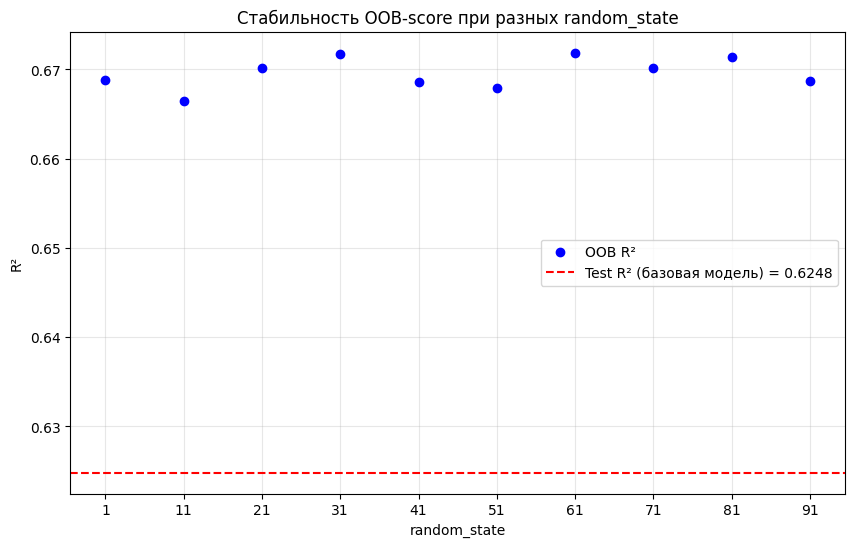

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# ------------------------------
# Предобработка данных (повтор)
# ------------------------------
data = pd.read_csv('../datasets/communities_and_crime.csv')
cols_to_drop = ['state', 'county', 'community', 'communityname', 'fold']
data.drop(columns=cols_to_drop, errors='ignore', inplace=True)
data = data.apply(pd.to_numeric, errors='coerce')

target = 'ViolentCrimesPerPop'
y = data[target]
X = data.drop(columns=[target])

na_frac = X.isnull().mean()
X = X.loc[:, na_frac <= 0.8]

imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42
)

# ------------------------------
# 1. Лучшая модель с oob_score=True
# ------------------------------
best_params = {
    'n_estimators': 300,
    'max_depth': 20,
    'max_features': 0.3,
    'min_samples_leaf': 3,
    'random_state': 42,
    'n_jobs': -1,
    'oob_score': True
}
rf_best = RandomForestRegressor(**best_params)
rf_best.fit(X_train, y_train)

oob_score = rf_best.oob_score_
print(f"OOB R² (random_state=42): {oob_score:.4f}")

# Предсказание на тесте и Test R²
y_pred = rf_best.predict(X_test)
test_r2 = r2_score(y_test, y_pred)
print(f"Test R² (random_state=42): {test_r2:.4f}")

# ------------------------------
# 2. Сравнение OOB-score и Test R²
# ------------------------------
print(f"Разница (OOB - Test R²): {oob_score - test_r2:.4f}")
if abs(oob_score - test_r2) < 0.05:
    print("OOB-score достаточно близок к тестовой метрике.")
else:
    print("Есть заметное расхождение между OOB и тестовой оценкой.")

# ------------------------------
# 3. Стабильность OOB-score: 10 моделей с разными random_state
# ------------------------------
random_states = np.arange(1, 101, 10)  # 1, 11, 21, ..., 91
oob_scores = []
test_r2_scores = []  # дополнительно соберём test R² для информации

for rs in random_states:
    params = best_params.copy()
    params['random_state'] = rs
    rf = RandomForestRegressor(**params)
    rf.fit(X_train, y_train)
    oob_scores.append(rf.oob_score_)
    test_r2_scores.append(r2_score(y_test, rf.predict(X_test)))

oob_mean = np.mean(oob_scores)
oob_std = np.std(oob_scores)
print("\nСтабильность OOB-score (10 random_state):")
print(f"Среднее OOB R²: {oob_mean:.4f}")
print(f"Стандартное отклонение: {oob_std:.4f}")

# ------------------------------
# 4. График: OOB-score для каждого random_state
# ------------------------------
plt.figure(figsize=(10, 6))
plt.scatter(random_states, oob_scores, color='blue', label='OOB R²', zorder=5)
plt.axhline(y=test_r2, color='red', linestyle='--', label=f'Test R² (базовая модель) = {test_r2:.4f}')
plt.xlabel('random_state')
plt.ylabel('R²')
plt.title('Стабильность OOB-score при разных random_state')
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(random_states)
plt.show()

## Градиентный бустинг

Градиентный бустинг строит ансамбль деревьев последовательно: каждое новое дерево учится исправлять
ошибки предыдущих. На практике это один из самых сильных подходов для табличных данных, потому что
он хорошо балансирует смещение и дисперсию и умеет «добирать» сложные нелинейные зависимости.

У бустинга есть разные популярные реализации: LightGBM, XGBoost и CatBoost. В этом проекте ты будешь
использовать **CatBoost** — библиотеку, которая нативно работает с категориальными признаками и часто
даёт высокое качество «из коробки».

*Твоя задача*: прогнозирование ежедневных продаж 1115 магазинов сети Rossmann. В данных есть история продаж
по датам, признаки промо-активностей и праздников, а также характеристики магазинов (тип, ассортимент,
конкуренты, интервалы промо). Это задача с временной структурой: присутствуют сезонность, тренды и
эффекты календаря, поэтому случайное разбиение легко приводит к утечке будущей информации. Чтобы
оценка качества была честной, train/test нужно разделять по времени.

![gb](../misc/images/gb.png)

### Задание 9. Подготовка данных Rossmann

1. Загрузи `../datasets/sales_train.csv` и `../datasets/sales_store.csv`. Объедини их по полю `Store`.
2. Преобразуй столбец `Date` в `datetime`. Извлеки признаки:
   год (`Year`), месяц (`Month`), день (`Day`), номер недели (`WeekOfYear`), день недели (`DayOfWeek`).
3. Заполни пропуски: `CompetitionDistance` — медианой; `CompetitionOpenSinceMonth` и
   `CompetitionOpenSinceYear` — значениями по умолчанию (1 и медиана года); `PromoInterval` — `'None'`.
4. Примени `np.log1p` к целевой переменной `Sales` → столбец `Sales_log`.
   Оставь только строки с `Open == 1`.
5. Разделение по времени: последние 6 недель от максимальной даты — тестовая выборка,
   всё остальное — обучающая.
6. Выведи размеры train и test, диапазон дат каждой выборки.

In [19]:
import pandas as pd
import numpy as np

# 1. Загрузка и объединение данных
sales_train = pd.read_csv('../datasets/sales_train.csv')
sales_store = pd.read_csv('../datasets/sales_store.csv')
data = sales_train.merge(sales_store, on='Store', how='left')

# 2. Преобразование Date и извлечение признаков времени
data['Date'] = pd.to_datetime(data['Date'])
data['Year'] = data['Date'].dt.year
data['Month'] = data['Date'].dt.month
data['Day'] = data['Date'].dt.day
data['WeekOfYear'] = data['Date'].dt.isocalendar().week.astype(int)  # номер недели по ISO
data['DayOfWeek'] = data['Date'].dt.dayofweek  # 0=пн, 6=вс

# 3. Заполнение пропусков
# CompetitionDistance – медианой
data['CompetitionDistance'] = data['CompetitionDistance'].fillna(
    data['CompetitionDistance'].median()
)

# CompetitionOpenSinceMonth – 1, CompetitionOpenSinceYear – медианой года
data['CompetitionOpenSinceMonth'] = data['CompetitionOpenSinceMonth'].fillna(1)
data['CompetitionOpenSinceYear'] = data['CompetitionOpenSinceYear'].fillna(
    data['CompetitionOpenSinceYear'].median()
)

# PromoInterval – строкой 'None'
data['PromoInterval'] = data['PromoInterval'].fillna('None')

# 4. Логарифмирование целевой переменной и фильтрация открытых магазинов
data['Sales_log'] = np.log1p(data['Sales'])
data = data[data['Open'] == 1].copy()

# 5. Разделение по времени (последние 6 недель – тест)
max_date = data['Date'].max()
cutoff_date = max_date - pd.DateOffset(weeks=6) + pd.DateOffset(days=1)
test = data[data['Date'] >= cutoff_date]
train = data[data['Date'] < cutoff_date]

# 6. Вывод размеров и диапазонов дат
print(f"Размер обучающей выборки: {train.shape}")
print(f"Размер тестовой выборки:   {test.shape}")
print(f"\nДиапазон дат обучающей выборки: {train['Date'].min().date()} – {train['Date'].max().date()}")
print(f"Диапазон дат тестовой выборки:   {test['Date'].min().date()} – {test['Date'].max().date()}")

C:\Users\User\AppData\Local\Temp\ipykernel_1696\3819569893.py:5: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  sales_train = pd.read_csv('../datasets/sales_train.csv')


Размер обучающей выборки: (804110, 23)
Размер тестовой выборки:   (40282, 23)

Диапазон дат обучающей выборки: 2013-01-01 – 2015-06-19
Диапазон дат тестовой выборки:   2015-06-20 – 2015-07-31


### Задание 10. Обучение CatBoost

1. Задай список признаков и список категориальных признаков (`cat_features`):
   `Store`, `DayOfWeek`, `StateHoliday`, `SchoolHoliday`, `StoreType`, `Assortment`, `PromoInterval`.
2. Создай `Pool` для train и test с указанием `cat_features`.
3. Обучи `CatBoostRegressor` с параметрами:
   - `iterations=1000, learning_rate=0.05, depth=8, l2_leaf_reg=3`;
   - `loss_function='RMSE', random_seed=42, early_stopping_rounds=100`.
   - Используй `eval_set=test_pool` для мониторинга качества на каждой итерации.
4. Выведи итоговые метрики на тестовой выборке в исходной шкале (через `np.expm1`): RMSE и MAE.

In [20]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ------------------------------------------------------------
# Данные уже подготовлены: train и test из предыдущего шага
# (предполагаем, что переменные train, test определены)
# ------------------------------------------------------------

# 1. Список признаков и категориальных признаков
# Исключаем неиспользуемые столбцы
drop_cols = ['Sales', 'Sales_log', 'Customers', 'Date', 'Open']
features = [col for col in train.columns if col not in drop_cols]

cat_features = ['Store', 'DayOfWeek', 'StateHoliday', 'SchoolHoliday',
                'StoreType', 'Assortment', 'PromoInterval']

# Проверим, что все категориальные признаки присутствуют
for cf in cat_features:
    assert cf in features, f"Признак {cf} не найден в списке фичей"

# 2. Создание Pool для train и test с указанием категориальных признаков
train_pool = Pool(data=train[features], label=train['Sales_log'],
                  cat_features=cat_features)
test_pool = Pool(data=test[features], label=test['Sales_log'],
                 cat_features=cat_features)

# 3. Обучение CatBoostRegressor с заданными параметрами
model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    l2_leaf_reg=3,
    loss_function='RMSE',
    random_seed=42,
    early_stopping_rounds=100,
    verbose=100  # печатать метрики каждые 100 итераций
)

model.fit(train_pool, eval_set=test_pool, verbose=100)

# 4. Метрики на тесте в исходной шкале продаж
pred_log = model.predict(test_pool)
true_log = test['Sales_log'].values

# Обратное преобразование логарифма
pred_sales = np.expm1(pred_log)
true_sales = np.expm1(true_log)

rmse = np.sqrt(mean_squared_error(true_sales, pred_sales))
mae = mean_absolute_error(true_sales, pred_sales)

print(f"\nИтоговые метрики на тестовой выборке (исходная шкала):")
print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")

0:	learn: 0.4168526	test: 0.4012378	best: 0.4012378 (0)	total: 497ms	remaining: 8m 16s
100:	learn: 0.1878100	test: 0.1711499	best: 0.1709126 (97)	total: 32.9s	remaining: 4m 52s
200:	learn: 0.1728003	test: 0.1586437	best: 0.1586111 (198)	total: 1m 8s	remaining: 4m 33s
300:	learn: 0.1646425	test: 0.1515183	best: 0.1514281 (299)	total: 1m 43s	remaining: 4m
400:	learn: 0.1592168	test: 0.1458089	best: 0.1458089 (400)	total: 2m 19s	remaining: 3m 27s
500:	learn: 0.1551983	test: 0.1428879	best: 0.1428879 (500)	total: 2m 55s	remaining: 2m 54s
600:	learn: 0.1523273	test: 0.1408260	best: 0.1408260 (600)	total: 3m 30s	remaining: 2m 19s
700:	learn: 0.1497533	test: 0.1386379	best: 0.1386379 (700)	total: 4m 6s	remaining: 1m 45s
800:	learn: 0.1475220	test: 0.1366622	best: 0.1366622 (800)	total: 4m 41s	remaining: 1m 9s
900:	learn: 0.1453166	test: 0.1345787	best: 0.1345787 (900)	total: 5m 16s	remaining: 34.8s
999:	learn: 0.1436728	test: 0.1332170	best: 0.1331740 (986)	total: 5m 51s	remaining: 0us

bestT

## Бонусное задание. Подбор гиперпараметров и интерпретация

В предыдущих заданиях ты обучил CatBoost с фиксированными гиперпараметрами. Теперь пора
автоматизировать их подбор и научиться интерпретировать предсказания модели. Ты познакомишься
с **Optuna**, современной библиотекой для оптимизации гиперпараметров, и с **SHAP** — инструментом
для объяснения предсказаний на основе теории игр.

### Задание 11. Подбор гиперпараметров с Optuna

В Задании 10 мы обучили CatBoost с фиксированными гиперпараметрами. Но как найти оптимальную
комбинацию? Перебор сеткой (`GridSearchCV`) работает для небольших пространств, но при большом числе
параметров быстро становится непрактичным.

**Optuna** — современная библиотека для автоматического подбора гиперпараметров. Она поддерживает
различные стратегии поиска:
- **TPE (Tree-structured Parzen Estimator)** — байесовская оптимизация, которая учитывает результаты
  предыдущих экспериментов и фокусируется на перспективных областях пространства параметров.
- **Random Search** — случайный перебор; простая, но часто неожиданно эффективная стратегия.
- **Grid Search** — полный перебор заданной сетки.

Optuna также умеет автоматически обрезать (pruning) неперспективные эксперименты, что экономит время.

Продолжай работать с данными Rossmann из Заданий 9–10.

1. Определи целевую функцию (`objective`) для Optuna:
   - внутри функции создай `CatBoostRegressor` с переданными гиперпараметрами;
   - пространство поиска:
     - `depth`: от 4 до 10 (целое);
     - `learning_rate`: от 0.01 до 0.3 (логарифмическая шкала);
     - `l2_leaf_reg`: от 1 до 10 (целое);
     - `iterations`: от 500 до 2000 (шаг 100);
     - `bagging_temperature`: от 0.0 до 1.0;
   - обучи модель с `early_stopping_rounds=50`;
   - верни RMSE на тестовой выборке (в исходной шкале через `np.expm1`).
2. Запусти три исследования (`study`) по 5 испытаний (`n_trials`) каждое:
   - исследование 1: `TPESampler(seed=42)`;
   - исследование 2: `RandomSampler(seed=42)`;
   - исследование 3: `TPESampler(seed=42)` с pruner `MedianPruner`.
3. Для каждого исследования выведи лучшие параметры и лучший RMSE.
4. Построй графики (используй `optuna.visualization`):
   - `plot_optimization_history` для каждой стратегии;
   - `plot_param_importances` для лучшего исследования.
5. Обучи финальную модель с лучшими параметрами. Выведи RMSE и MAE в исходной шкале.
   Сравни с базовой моделью из Задания 10.

### Задание 12. Интерпретация модели с SHAP

Когда модель обучена, важно понимать, **почему** она принимает те или иные решения. Библиотека
**SHAP** (SHapley Additive exPlanations) основана на значениях Шепли из теории игр и позволяет
оценить вклад каждого признака в предсказание — как глобально (для всей модели), так и локально
(для конкретного объекта).

SHAP-значения обладают важными свойствами:
- **Аддитивность**: сумма SHAP-значений всех признаков + базовое значение = предсказание модели.
- **Консистентность**: если признак вносит больший вклад, его SHAP-значение не может уменьшиться.
- **Локальная точность**: объяснение точно воспроизводит предсказание модели.

Используй лучшую модель CatBoost из Задания 11.

1. Вычисли SHAP-значения для тестовой выборки с помощью `shap.TreeExplainer`.
2. Глобальная важность признаков:
   - Построй `shap.summary_plot` (beeswarm-диаграмму): для каждого признака показано
     распределение SHAP-значений по всем объектам.
   - Построй `shap.summary_plot` с `plot_type="bar"` — столбчатую диаграмму средних абсолютных
     SHAP-значений.
   - Сравни топ-5 признаков по SHAP с `feature_importances_` CatBoost. Совпадают ли они?
3. Локальные объяснения — выбери три конкретных примера из тестовой выборки:
   - объект с самым высоким предсказанием продаж;
   - объект с самым низким предсказанием продаж;
   - объект, на котором модель ошиблась сильнее всего.
   Для каждого из них построй `shap.waterfall_plot`, показывающий вклад каждого признака
   в предсказание этого конкретного объекта.
4. Построй `shap.dependence_plot` для двух наиболее важных признаков. Опиши наблюдаемые
   зависимости.
5. Напиши выводы:
   - Какие признаки оказывают наибольшее влияние на прогноз продаж?
   - Чем SHAP-интерпретация отличается от встроенной `feature_importances_`?
   - В каких ситуациях модель завышает/занижает прогноз?